In [89]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge,LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [90]:
# 1.Loading the dataset
df=pd.read_csv("ToyotaCorolla_-_MLR[1].csv") 

In [4]:
df.info() # getting the basic information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
df.head() # Preview of dataset 

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [6]:
df.shape # understanding the number of rows and columns

(1436, 11)

In [7]:
# Checking for  missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [8]:
# seeing the duplicate values
df[df.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [91]:
# droping the duplicates
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum() # shows duplicated values are removed

np.int64(0)

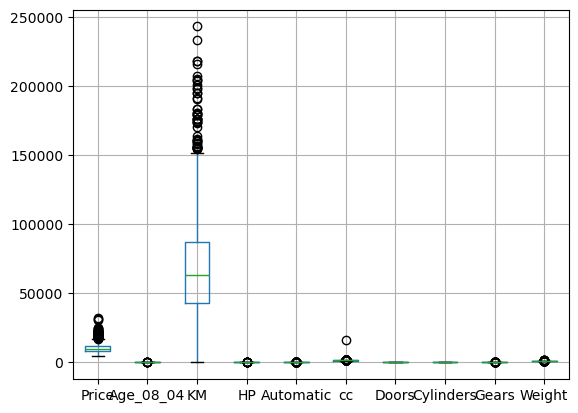

In [10]:
# checking for outliers
df.boxplot()
plt.show()

In [92]:
# Outlier treatment using IQR capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25) # calculating Q1
    Q3= df[columns].quantile(0.75) # calculating Q3
    IQR= Q3-Q1 # calculating IQR
    lower_extreme= Q1-1.5*IQR # calculating Lower_extreme
    upper_extreme= Q3+1.5*IQR # calculating upper extreme
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
# replacing values less than lower_extreme with lower_extreme and values greater than upper_extreme with upper_extreme
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

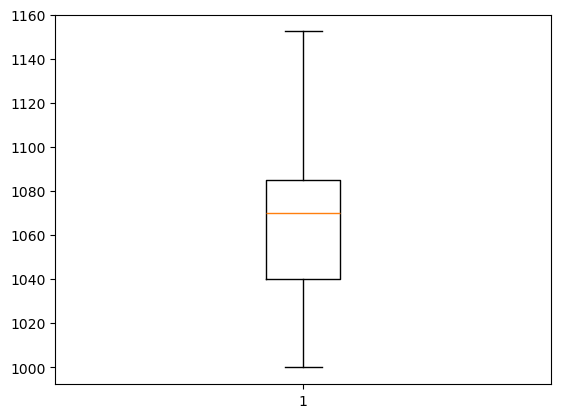

In [12]:
plt.boxplot(df[col])
plt.show() # shows outliers are treated

In [13]:
num_df= df.select_dtypes(include=('float64','int64')) # selecting numerical datatypes
# Statistical summary
Summary=pd.DataFrame({
    "Mean":num_df.mean(),
    "Median":num_df.median(),
    "Std_dev":num_df.std(),
    "Min":num_df.min(),
    "Max":num_df.max(),
    "IQR": num_df.quantile(0.75) - num_df.quantile(0.25)})
print(Summary)

                   Mean   Median       Std_dev     Min        Max      IQR
Price      10495.964460   9900.0   2977.598549  4350.0   17200.00   3500.0
Age_08_04     55.992334     61.0     18.529725     5.0      80.00     26.0
KM         67644.520383  63451.0  34725.393258     1.0  153103.75  44041.5
HP           101.093380    110.0     13.146145    69.0     140.00     20.0
Automatic      0.000000      0.0      0.000000     0.0       0.00      0.0
cc          1558.327526   1600.0    168.788311  1300.0    1900.00    200.0
Doors          4.032753      4.0      0.952667     2.0       5.00      2.0
Cylinders      4.000000      4.0      0.000000     4.0       4.00      0.0
Gears          5.000000      5.0      0.000000     5.0       5.00      0.0
Weight      1068.520906   1070.0     37.722708  1000.0    1152.50     45.0


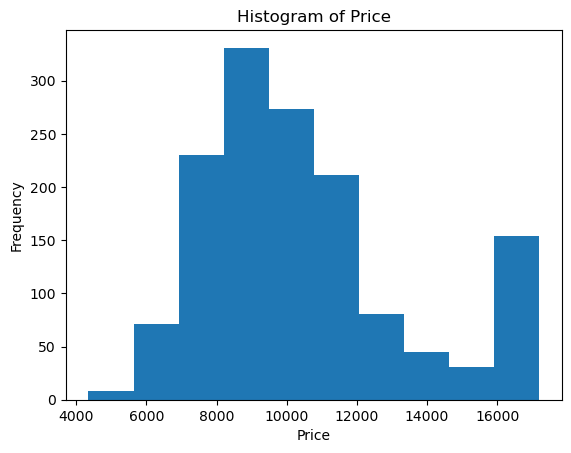

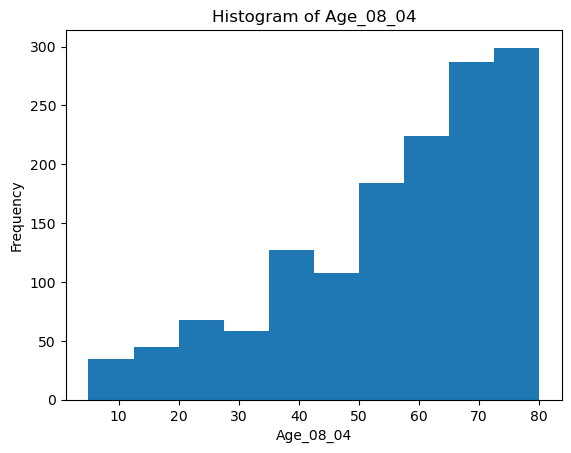

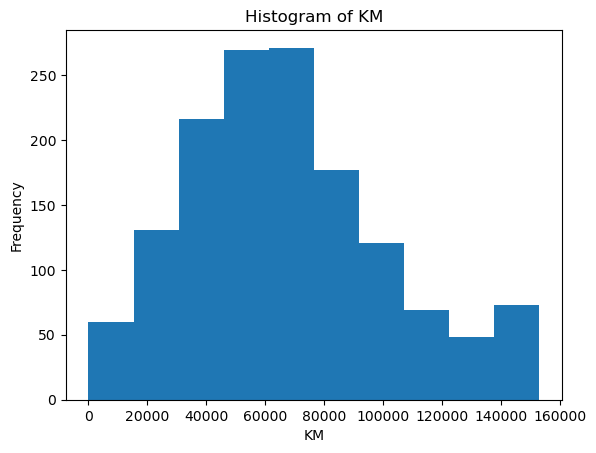

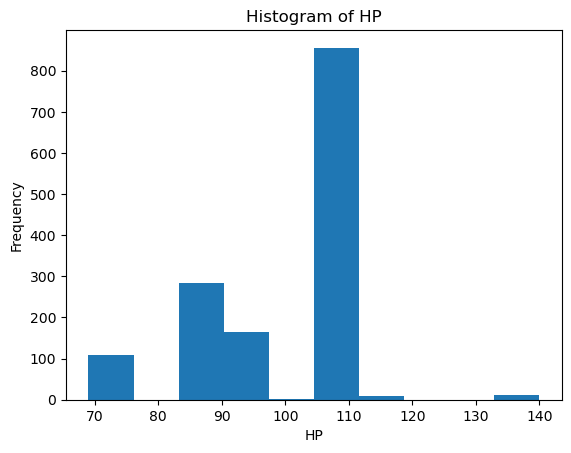

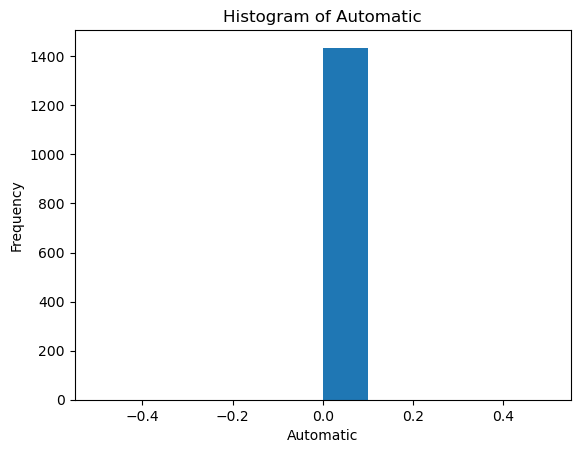

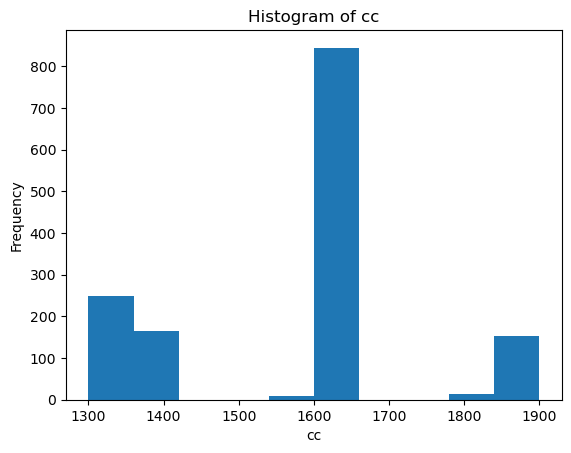

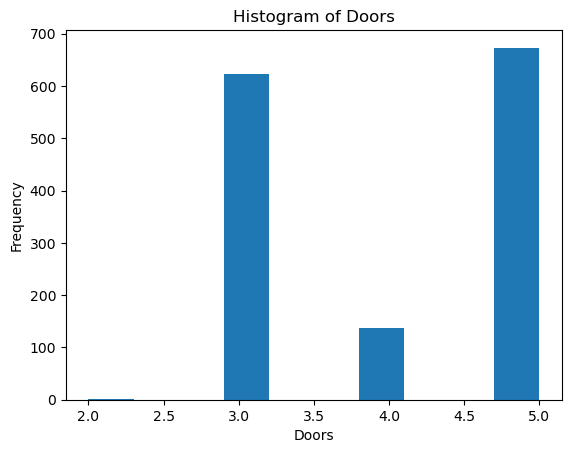

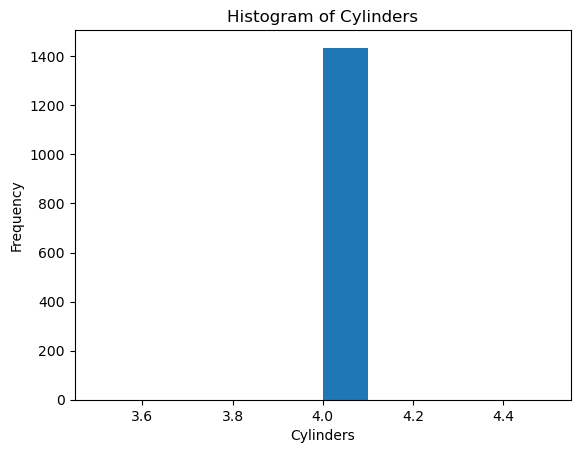

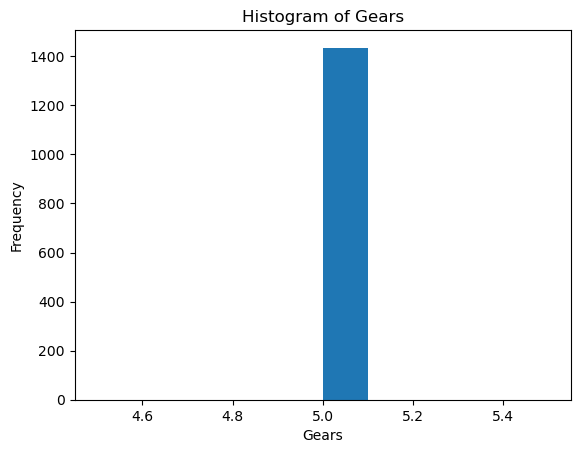

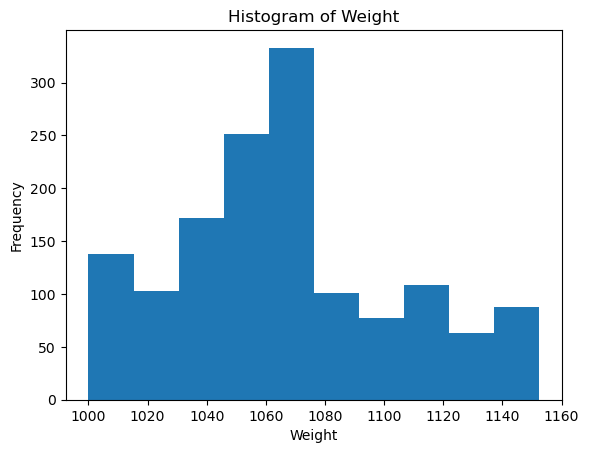

In [14]:
# Histogram
for col in num_df.columns: # refering to numerical columns
    plt.figure()
    plt.hist(num_df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.show()

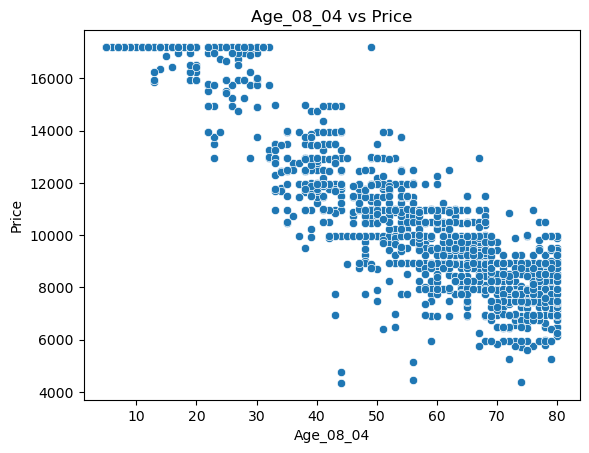

In [15]:
# scatterplot for Age vs Price
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.title("Age_08_04 vs Price")
plt.show()


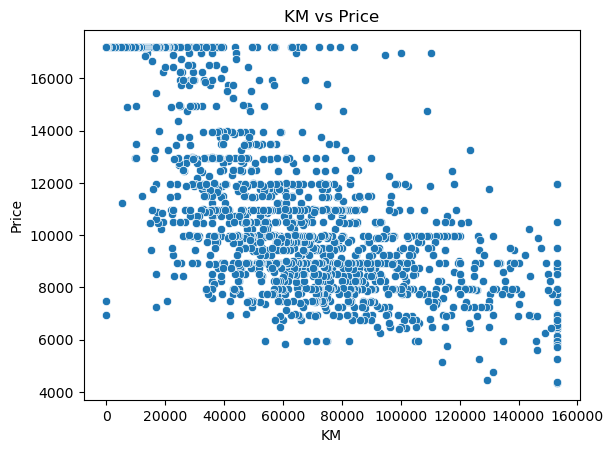

In [17]:
sns.scatterplot(x='KM', y='Price', data=df)
plt.title("KM vs Price")
plt.show()

In [93]:
#Feature & Target Separation
target= df[['Price']]
features= df.drop(columns=['Price'])

2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [94]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=150)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 10)
(287, 10)
(1148, 1)
(287, 1)


In [95]:
# Feature Scaling
std_sca=StandardScaler()

In [96]:
# Scaling x train features
x_train[['Age_08_04','KM','HP','cc','Weight']]= std_sca.fit_transform(x_train[['Age_08_04','KM','HP','cc','Weight']]) # for training use fit_transform
x_train.head()


,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1179,1.125526,0.685132,Petrol,0.696909,0.0,0.229569,5,4,5.0,0.165108
278,-0.963177,-0.630630,Petrol,0.696909,0.0,0.229569,3,4,5.0,-0.356477
60,-1.820080,-0.882291,Petrol,-0.276481,0.0,-0.924179,5,4,5.0,1.077880
267,-0.856064,-0.556628,Diesel,-0.800614,0.0,1.960190,5,4,5.0,2.186247
777,0.643517,0.234300,Petrol,-1.100119,0.0,-1.501053,3,4,5.0,-1.399645


In [97]:
# Scaling x test features
x_test[['Age_08_04','KM','HP','cc','Weight']]= std_sca.transform(x_test[['Age_08_04','KM','HP','cc','Weight']])# for testing use tranform
x_test.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
514,-0.052717,-0.466501,Petrol,-0.276481,0.0,-0.924179,3,4,5.0,0.425900
32,-1.552298,-1.104719,Petrol,-0.276481,0.0,-0.924179,3,4,5.0,0.817088
871,0.589961,-0.179883,Petrol,0.696909,0.0,0.229569,3,4,5.0,-0.486873
289,-1.070290,-0.712384,Petrol,0.696909,0.0,0.229569,3,4,5.0,-0.747665
512,-0.374056,-0.439240,Petrol,-0.276481,0.0,-0.924179,3,4,5.0,-1.138853


In [98]:
# Labelling
from sklearn.preprocessing import OneHotEncoder


In [99]:
one_hot=OneHotEncoder()
# Applying one hot encoder separately on training and testing data
df_fuel_train=pd.DataFrame(one_hot.fit_transform(x_train[['Fuel_Type']]).toarray(),columns=['Diesel','Petrol','CNG'],index=x_train.index)
df_fuel_test=pd.DataFrame(one_hot.transform(x_test[['Fuel_Type']]).toarray(),columns=['Diesel','Petrol','CNG'], index=x_test.index)
df_fuel_test

,Diesel,Petrol,CNG
514,0.0,0.0,1.0
32,0.0,0.0,1.0
871,0.0,0.0,1.0
289,0.0,0.0,1.0
512,0.0,0.0,1.0
...,...,...,...
707,0.0,0.0,1.0
1382,0.0,0.0,1.0
31,0.0,0.0,1.0
1261,0.0,0.0,1.0


In [100]:
# Merging encoded columns
x_train_final= pd.concat([df_fuel_train,x_train],axis=1)
x_test_final=pd.concat([df_fuel_test,x_test],axis=1)


In [101]:
# Drop the original
x_train_final.drop(columns=['Fuel_Type'], inplace=True)
x_test_final.drop(columns=['Fuel_Type'], inplace=True)


In [102]:
x_train_final # encoded 

,Diesel,Petrol,CNG,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1179,0.0,0.0,1.0,1.125526,0.685132,0.696909,0.0,0.229569,5,4,5.0,0.165108
278,0.0,0.0,1.0,-0.963177,-0.630630,0.696909,0.0,0.229569,3,4,5.0,-0.356477
60,0.0,0.0,1.0,-1.820080,-0.882291,-0.276481,0.0,-0.924179,5,4,5.0,1.077880
267,0.0,1.0,0.0,-0.856064,-0.556628,-0.800614,0.0,1.960190,5,4,5.0,2.186247
777,0.0,0.0,1.0,0.643517,0.234300,-1.100119,0.0,-1.501053,3,4,5.0,-1.399645
...,...,...,...,...,...,...,...,...,...,...,...,...
306,0.0,0.0,1.0,-0.748951,-0.839102,0.696909,0.0,0.229569,3,4,5.0,-0.747665
496,0.0,0.0,1.0,-0.052717,-0.290927,0.696909,0.0,0.229569,3,4,5.0,-0.486873
25,0.0,0.0,1.0,-1.659411,-1.134601,0.696909,0.0,0.229569,3,4,5.0,1.338673
442,0.0,0.0,1.0,-0.106273,0.184205,0.696909,0.0,0.229569,5,4,5.0,0.295504


In [103]:
# Model 1: with all features
lin_reg=LinearRegression()
lin_reg.fit(x_train_final,y_train)

LinearRegression()

In [45]:
lin_reg.coef_

array([[-7.22518480e+02,  3.26419732e+02,  3.96098749e+02,
        -2.01369016e+03, -5.56499425e+02,  3.46527449e+02,
        -3.55271368e-14, -3.80172649e+02, -8.49032624e+01,
         0.00000000e+00,  0.00000000e+00,  8.85237012e+02]])

In [46]:
coef_df = pd.DataFrame({
    "Feature": x_train_final.columns,
    "Coefficient": lin_reg.coef_.flatten()
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
11,Weight,8.852370e+02
2,CNG,3.960987e+02
5,HP,3.465274e+02
1,Petrol,3.264197e+02
9,Cylinders,0.000000e+00
10,Gears,0.000000e+00
6,Automatic,-3.552714e-14
8,Doors,-8.490326e+01
7,cc,-3.801726e+02
4,KM,-5.564994e+02


In [47]:
#### Testing_Validation
y_pred=lin_reg.predict(x_test_final)
r2_score(y_test,y_pred)

0.8730483755781904

In [62]:
# mean_squared_error
mse= mean_squared_error(y_test,y_pred)
#### RMSE(Root_Mean_Squared_Error)
rmse= np.sqrt(mse)
#### Mean_Absolute_Error
mae= mean_absolute_error(y_test,y_pred)
print("MSE:", mse)
print("RMSE:",rmse)
print("MAE:",mae)


MSE: 955569.8712683314
RMSE: 977.5325423065625
MAE: 780.6757721759174


In [49]:
selected_features = ['Age_08_04', 'KM', 'HP', 'Weight']
X2 = df[selected_features]
X2

,Age_08_04,KM,HP,Weight
0,23.0,46986.0,90.0,1152.5
1,23.0,72937.0,90.0,1152.5
2,24.0,41711.0,90.0,1152.5
3,26.0,48000.0,90.0,1152.5
4,30.0,38500.0,90.0,1152.5
...,...,...,...,...
1430,69.0,20544.0,86.0,1025.0
1431,72.0,19000.0,86.0,1015.0
1432,71.0,17016.0,86.0,1015.0
1433,70.0,16916.0,86.0,1015.0


In [50]:
#Splitting the dataset
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,target,train_size=0.8,random_state=100)
print(X2_train.shape)
print(X2_test.shape)
print(y2_train.shape)
print(y2_test.shape)

(1148, 4)
(287, 4)
(1148, 1)
(287, 1)


In [53]:
#Scaling the selected features
scaler2 = StandardScaler()
X2_train= scaler2.fit_transform(X2_train)
X2_test= scaler2.transform(X2_test)

In [55]:
# Model Building for MLR
lin_reg2=LinearRegression()
lin_reg2.fit(X2_train, y2_train)

LinearRegression()

In [56]:
lin_reg2.coef_

array([[-2009.54704403,  -648.65938825,   268.72224699,   588.00862128]])

In [63]:
#### Testing_Validation
y_pred2=lin_reg2.predict(X2_test)

In [64]:
#R2 score
r2score=r2_score(y2_test,y_pred2)
# mean_squared_error
mse1= mean_squared_error(y2_test,y_pred2)
#### RMSE(Root_Mean_Squared_Error)
rmse1=np.sqrt(mse1)
#### Mean_Absolute_Error
mae1= mean_absolute_error(y2_test,y_pred2)
print("R2score:",r2score)
print("MSE:", mse1)
print("RMSE:",rmse1)
print("MAE:",mae1)


R2score: 0.843229867768471
MSE: 1328418.78711475
RMSE: 1152.5705128601676
MAE: 855.8473586141935


In [ ]:
# Model 3 :with highly uncorrelated features

In [65]:
selected_features1 = ['Automatic','cc','Doors','Cylinders','Gears','Weight']
X3 = df[selected_features1]
X3

,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.0,1900.0,3,4,5.0,1152.5
1,0.0,1900.0,3,4,5.0,1152.5
2,0.0,1900.0,3,4,5.0,1152.5
3,0.0,1900.0,3,4,5.0,1152.5
4,0.0,1900.0,3,4,5.0,1152.5
...,...,...,...,...,...,...
1430,0.0,1300.0,3,4,5.0,1025.0
1431,0.0,1300.0,3,4,5.0,1015.0
1432,0.0,1300.0,3,4,5.0,1015.0
1433,0.0,1300.0,3,4,5.0,1015.0


In [66]:
#Splitting the dataset
X3_train,X3_test,y3_train,y3_test=train_test_split(X3,target,train_size=0.8,random_state=100)
print(X3_train.shape)
print(X3_test.shape)
print(y3_train.shape)
print(y3_test.shape)

(1148, 6)
(287, 6)
(1148, 1)
(287, 1)


In [67]:
#Scaling the selected features
scaler3 = StandardScaler()
X3_train= scaler3.fit_transform(X3_train)
X3_test= scaler3.transform(X3_test)

In [68]:
# Model Building for MLR
lin_reg3=LinearRegression()
lin_reg3.fit(X3_train, y3_train)

LinearRegression()

In [69]:
lin_reg3.coef_

array([[    0.        , -1536.62371408,  -226.60170422,     0.        ,
            0.        ,  2807.0264962 ]])

In [70]:
y_pred3=lin_reg3.predict(X3_test)

In [71]:
#R2 score
r2score2=r2_score(y3_test,y_pred3)
# mean_squared_error
mse2= mean_squared_error(y3_test,y_pred3)
#### RMSE(Root_Mean_Squared_Error)
rmse2=np.sqrt(mse2)
#### Mean_Absolute_Error
mae2= mean_absolute_error(y3_test,y_pred3)
print("R2score:",r2score2)
print("MSE:", mse2)
print("RMSE:",rmse2)
print("MAE:",mae2)


R2score: 0.2570243156491274
MSE: 6295732.761158181
RMSE: 2509.12988128518
MAE: 2030.0730167928084


In [73]:
# Lasso on model 1-base model with all features 

In [104]:
### Train and validate the model
lasso =Lasso(alpha=1.0, max_iter=1000)
lasso.fit(x_train_final,y_train)
y_pred_lasso= lasso.predict(x_test_final)
r2_score(y_test,y_pred_lasso)

0.8727144542956038

In [85]:
coef_df = pd.DataFrame({
    "Feature": x_train_final.columns,
    "Lasso_Coefficient": lasso.coef_
})
print(coef_df)

      Feature  Lasso_Coefficient
0      Diesel        -881.447250
1      Petrol           0.000000
2         CNG         135.582191
3   Age_08_04       -2014.829499
4          KM        -561.079547
5          HP         328.178434
6   Automatic           0.000000
7          cc        -356.594361
8       Doors         -81.706489
9   Cylinders           0.000000
10      Gears           0.000000
11     Weight         877.441209


In [76]:
#RIDGE on model1

In [105]:
ridge=Ridge(alpha=1,max_iter=1000)
ridge.fit(x_train_final,y_train)
y_pred_ridge=ridge.predict(x_test_final)
r2_score(y_test,y_pred_ridge)

0.8728959572089234